# CSV → Parquet Conversion

Converts raw CSV datasets to parquet. Shared imports are at the top; each dataset has its own section.

Output layout:
```
data/parquet/
├── daily/fleet-daily-YYYY-MM.parquet      (60 files, one per month)
├── monthly/fleet-monthly-YYYY.parquet     (5 files, one per year)
└── mmsi-daily/mmsi-daily-YYYY.parquet     (5 files, one per year)
```

In [15]:

import glob
import os
from pathlib import Path
from itertools import groupby

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

import geopandas as gpd

## Fleet Daily

One parquet per calendar month → `data/parquet/daily/fleet-daily-YYYY-MM.parquet`

In [5]:
DATA_DIR = Path("../data")
OUTPUT_DIR = DATA_DIR / "parquet" / "daily"
OUTPUT_DIR.mkdir(exist_ok=True)

YEARS = [2020, 2021, 2022, 2023, 2024]

# Parquet schema with downcasted types
ARROW_SCHEMA = pa.schema([
    pa.field("date",          pa.date32()),
    pa.field("cell_ll_lat",   pa.float32()),
    pa.field("cell_ll_lon",   pa.float32()),
    pa.field("flag",          pa.dictionary(pa.int16(), pa.string())),
    pa.field("geartype",      pa.dictionary(pa.int8(),  pa.string())),
    pa.field("hours",         pa.float32()),
    pa.field("fishing_hours", pa.float32()),
    pa.field("mmsi_present",  pa.int16()),
])

# pandas dtypes used when reading each CSV
CSV_DTYPES = {
    "cell_ll_lat":   "float32",
    "cell_ll_lon":   "float32",
    "flag":          "category",
    "geartype":      "category",
    "hours":         "float32",
    "fishing_hours": "float32",
    "mmsi_present":  "int16",
}

In [3]:
def csv_path_to_year_month(path: Path) -> tuple[int, int]:
    """Extract (year, month) from a fleet CSV filename."""
    # filename: fleet-daily-csvs-100-v3-YYYY-MM-DD.csv
    date_part = path.stem.split("-v3-")[1]   # YYYY-MM-DD
    year, month, _ = date_part.split("-")
    return int(year), int(month)


def convert_month(csv_paths: list[Path], output_path: Path) -> int:
    """
    Stream-convert a list of daily CSVs (one month) into a single parquet file.
    Returns total row count written.
    """
    frames = []
    for csv_path in sorted(csv_paths):
        df = pd.read_csv(
            csv_path,
            dtype=CSV_DTYPES,
            parse_dates=["date"],
        )
        frames.append(df)

    month_df = pd.concat(frames, ignore_index=True)

    table = pa.Table.from_pandas(month_df, schema=ARROW_SCHEMA, preserve_index=False)
    pq.write_table(table, output_path, compression="snappy")

    return len(month_df)


def convert_year(year: int, skip_existing: bool = True) -> None:
    """Convert all daily CSVs for a given year into monthly parquet files."""
    folder = DATA_DIR / f"fleet-daily-{year}"
    csv_paths = sorted(folder.glob("fleet-daily-csvs-100-v3-*.csv"))

    if not csv_paths:
        print(f"  [!] No CSVs found in {folder}")
        return

    # Group by month
    def month_key(p):
        return csv_path_to_year_month(p)[1]

    for month, group in groupby(csv_paths, key=month_key):
        output_path = OUTPUT_DIR / f"fleet-daily-{year}-{month:02d}.parquet"

        if skip_existing and output_path.exists():
            print(f"  skip  {output_path.name} (already exists)")
            continue

        paths = list(group)
        n_rows = convert_month(paths, output_path)
        size_mb = output_path.stat().st_size / 1e6
        print(f"  wrote {output_path.name}  ({len(paths)} days, {n_rows:,} rows, {size_mb:.1f} MB)")

In [6]:
for year in YEARS:
    print(f"\n=== {year} ===")
    convert_year(year)


=== 2020 ===
  skip  fleet-daily-2020-01.parquet (already exists)
  skip  fleet-daily-2020-02.parquet (already exists)
  skip  fleet-daily-2020-03.parquet (already exists)
  skip  fleet-daily-2020-04.parquet (already exists)
  skip  fleet-daily-2020-05.parquet (already exists)
  skip  fleet-daily-2020-06.parquet (already exists)
  skip  fleet-daily-2020-07.parquet (already exists)
  skip  fleet-daily-2020-08.parquet (already exists)
  skip  fleet-daily-2020-09.parquet (already exists)
  skip  fleet-daily-2020-10.parquet (already exists)
  skip  fleet-daily-2020-11.parquet (already exists)
  skip  fleet-daily-2020-12.parquet (already exists)

=== 2021 ===
  wrote fleet-daily-2021-01.parquet  (31 days, 19,907,741 rows, 129.5 MB)
  wrote fleet-daily-2021-02.parquet  (28 days, 19,366,498 rows, 124.8 MB)
  wrote fleet-daily-2021-03.parquet  (31 days, 22,992,436 rows, 151.7 MB)
  wrote fleet-daily-2021-04.parquet  (30 days, 23,920,276 rows, 156.0 MB)
  wrote fleet-daily-2021-05.parquet  (31

## Verification

Sanity-check a sample parquet file: schema, row count, and a preview.

In [5]:
sample = OUTPUT_DIR / "fleet-daily-2020-01.parquet"

meta = pq.read_metadata(sample)
print(f"File:       {sample.name}")
print(f"Rows:       {meta.num_rows:,}")
print(f"Row groups: {meta.num_row_groups}")
print(f"Size:       {sample.stat().st_size / 1e6:.1f} MB")
print()
print(pq.read_schema(sample))

df_sample = pd.read_parquet(sample)
print()
print(df_sample.dtypes)
print()
df_sample.head()

File:       fleet-daily-2020-01.parquet
Rows:       17,485,243
Row groups: 17
Size:       114.2 MB

date: date32[day]
cell_ll_lat: float
cell_ll_lon: float
flag: dictionary<values=string, indices=int16, ordered=0>
geartype: dictionary<values=string, indices=int8, ordered=0>
hours: float
fishing_hours: float
mmsi_present: int16
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 1074

date               object
cell_ll_lat       float32
cell_ll_lon       float32
flag             category
geartype         category
hours             float32
fishing_hours     float32
mmsi_present        int16
dtype: object



,date,cell_ll_lat,cell_ll_lon,flag,geartype,hours,fishing_hours,mmsi_present
0,2020-01-01,24.700001,119.120003,AFG,trawlers,0.0411,0.0,1
1,2020-01-01,24.700001,119.050003,AFG,trawlers,0.1416,0.0,1
2,2020-01-01,24.700001,119.150002,AFG,trawlers,0.2283,0.0,1
3,2020-01-01,24.700001,119.160004,AFG,trawlers,0.0569,0.0,1
4,2020-01-01,24.700001,119.110001,AFG,trawlers,0.1761,0.0,1


In [9]:
# Summary: output file sizes across all years
parquet_files = sorted(OUTPUT_DIR.glob("fleet-daily-*.parquet"))
total_mb = sum(f.stat().st_size for f in parquet_files) / 1e6
print(f"{'File':<35} {'MB':>8}")
print("-" * 44)
for f in parquet_files:
    print(f"  {f.name:<33} {f.stat().st_size / 1e6:>7.1f}")
print("-" * 44)
print(f"  {'TOTAL':<33} {total_mb:>7.1f}")

File                                      MB
--------------------------------------------
  fleet-daily-2020-01.parquet         114.2
  fleet-daily-2020-02.parquet         106.8
  fleet-daily-2020-03.parquet         128.3
  fleet-daily-2020-04.parquet         137.3
  fleet-daily-2020-05.parquet         125.9
  fleet-daily-2020-06.parquet         126.8
  fleet-daily-2020-07.parquet         126.1
  fleet-daily-2020-08.parquet         136.4
  fleet-daily-2020-09.parquet         155.8
  fleet-daily-2020-10.parquet         152.3
  fleet-daily-2020-11.parquet         143.4
  fleet-daily-2020-12.parquet         126.9
  fleet-daily-2021-01.parquet         129.5
  fleet-daily-2021-02.parquet         124.8
  fleet-daily-2021-03.parquet         151.7
  fleet-daily-2021-04.parquet         156.0
  fleet-daily-2021-05.parquet         148.7
  fleet-daily-2021-06.parquet         149.6
  fleet-daily-2021-07.parquet         145.5
  fleet-daily-2021-08.parquet         158.7
  fleet-daily-2021-09.parquet 

## Fleet Monthly

One parquet per year → `data/parquet/monthly/fleet-monthly-YYYY.parquet`

In [10]:
MONTHLY_OUTPUT_DIR = DATA_DIR / "parquet" / "monthly"
MONTHLY_OUTPUT_DIR.mkdir(exist_ok=True)

MONTHLY_ARROW_SCHEMA = pa.schema([
    pa.field("date",          pa.date32()),
    pa.field("year",          pa.int16()),
    pa.field("month",         pa.int8()),
    pa.field("cell_ll_lat",   pa.float32()),
    pa.field("cell_ll_lon",   pa.float32()),
    pa.field("flag",          pa.dictionary(pa.int16(), pa.string())),
    pa.field("geartype",      pa.dictionary(pa.int8(),  pa.string())),
    pa.field("hours",         pa.float32()),
    pa.field("fishing_hours", pa.float32()),
    pa.field("mmsi_present",  pa.int16()),
])

MONTHLY_CSV_DTYPES = {
    "year":          "int16",
    "month":         "int8",
    "cell_ll_lat":   "float32",
    "cell_ll_lon":   "float32",
    "flag":          "category",
    "geartype":      "category",
    "hours":         "float32",
    "fishing_hours": "float32",
    "mmsi_present":  "int16",
}

In [11]:
def convert_fleet_monthly_year(year: int, skip_existing: bool = True) -> None:
    """Convert all monthly CSVs for a given year into a single parquet file."""
    folder = DATA_DIR / f"fleet-monthly-{year}"
    csv_paths = sorted(folder.glob("fleet-monthly-csvs-10-v3-*.csv"))

    if not csv_paths:
        print(f"  [!] No CSVs found in {folder}")
        return

    output_path = MONTHLY_OUTPUT_DIR / f"fleet-monthly-{year}.parquet"

    if skip_existing and output_path.exists():
        print(f"  skip  {output_path.name} (already exists)")
        return

    frames = []
    for csv_path in csv_paths:
        df = pd.read_csv(csv_path, dtype=MONTHLY_CSV_DTYPES, parse_dates=["date"])
        frames.append(df)

    year_df = pd.concat(frames, ignore_index=True)
    table = pa.Table.from_pandas(year_df, schema=MONTHLY_ARROW_SCHEMA, preserve_index=False)
    pq.write_table(table, output_path, compression="snappy")

    size_mb = output_path.stat().st_size / 1e6
    print(f"  wrote {output_path.name}  ({len(csv_paths)} months, {len(year_df):,} rows, {size_mb:.1f} MB)")

In [12]:
for year in YEARS:
    convert_fleet_monthly_year(year)

  wrote fleet-monthly-2020.parquet  (12 months, 12,603,878 rows, 88.5 MB)
  wrote fleet-monthly-2021.parquet  (12 months, 12,954,173 rows, 92.7 MB)
  wrote fleet-monthly-2022.parquet  (12 months, 13,463,690 rows, 103.9 MB)
  wrote fleet-monthly-2023.parquet  (12 months, 14,560,171 rows, 108.9 MB)
  wrote fleet-monthly-2024.parquet  (12 months, 13,838,619 rows, 104.8 MB)


In [13]:
sample = MONTHLY_OUTPUT_DIR / "fleet-monthly-2020.parquet"
meta = pq.read_metadata(sample)
print(f"Rows: {meta.num_rows:,}  |  Size: {sample.stat().st_size / 1e6:.1f} MB")
pd.read_parquet(sample).head()

Rows: 12,603,878  |  Size: 88.5 MB


,date,year,month,cell_ll_lat,cell_ll_lon,flag,geartype,hours,fishing_hours,mmsi_present
0,2020-01-01,2020,1,24.600000,118.800003,AFG,trawlers,0.1094,0.0,1
1,2020-01-01,2020,1,24.600000,118.900002,AFG,trawlers,0.7241,0.0,1
2,2020-01-01,2020,1,24.700001,118.900002,AFG,trawlers,2.2177,0.0,1
3,2020-01-01,2020,1,24.700001,118.699997,AFG,trawlers,0.3844,0.0,1
4,2020-01-01,2020,1,24.700001,118.800003,AFG,trawlers,2.5272,0.0,1


## MMSI Daily

One parquet per year → `data/parquet/mmsi-daily/mmsi-daily-YYYY.parquet`

Uses `ParquetWriter` to write month-by-month, keeping peak RAM to ~one month of data.

In [16]:
MMSI_OUTPUT_DIR = DATA_DIR / "parquet" / "mmsi-daily"
MMSI_OUTPUT_DIR.mkdir(exist_ok=True)

MMSI_ARROW_SCHEMA = pa.schema([
    pa.field("date",          pa.date32()),
    pa.field("cell_ll_lat",   pa.float32()),
    pa.field("cell_ll_lon",   pa.float32()),
    pa.field("mmsi",          pa.string()),
    pa.field("hours",         pa.float32()),
    pa.field("fishing_hours", pa.float32()),
])

MMSI_CSV_DTYPES = {
    "cell_ll_lat":   "float32",
    "cell_ll_lon":   "float32",
    "mmsi":          "str",
    "hours":         "float32",
    "fishing_hours": "float32",
}

In [17]:
def convert_mmsi_daily_year(year: int, skip_existing: bool = True) -> None:
    """
    Convert all daily MMSI CSVs for a given year into a single parquet file.
    Writes month-by-month via ParquetWriter to cap peak RAM at ~one month of data.
    """
    folder = DATA_DIR / f"mmsi-daily-{year}"
    csv_paths = sorted(folder.glob("mmsi-daily-csvs-10-v3-*.csv"))

    if not csv_paths:
        print(f"  [!] No CSVs found in {folder}")
        return

    output_path = MMSI_OUTPUT_DIR / f"mmsi-daily-{year}.parquet"

    if skip_existing and output_path.exists():
        print(f"  skip  {output_path.name} (already exists)")
        return

    # csv_path_to_year_month works here too: splits on "-v3-" → "YYYY-MM-DD"
    def month_key(p):
        return csv_path_to_year_month(p)[1]

    total_rows = 0
    with pq.ParquetWriter(output_path, MMSI_ARROW_SCHEMA, compression="snappy") as writer:
        for month, group in groupby(csv_paths, key=month_key):
            frames = [
                pd.read_csv(p, dtype=MMSI_CSV_DTYPES, parse_dates=["date"])
                for p in group
            ]
            month_df = pd.concat(frames, ignore_index=True)
            table = pa.Table.from_pandas(month_df, schema=MMSI_ARROW_SCHEMA, preserve_index=False)
            writer.write_table(table)
            total_rows += len(month_df)
            print(f"    {year}-{month:02d}  {len(month_df):,} rows")

    size_mb = output_path.stat().st_size / 1e6
    print(f"  wrote {output_path.name}  ({len(csv_paths)} days, {total_rows:,} rows, {size_mb:.1f} MB)")

In [18]:
for year in YEARS:
    print(f"\n=== {year} ===")
    convert_mmsi_daily_year(year)


=== 2020 ===
    2020-01  4,033,994 rows
    2020-02  3,653,381 rows
    2020-03  4,623,624 rows
    2020-04  4,889,025 rows
    2020-05  4,146,009 rows
    2020-06  4,234,359 rows
    2020-07  4,283,016 rows
    2020-08  4,917,462 rows
    2020-09  5,942,508 rows
    2020-10  5,626,621 rows
    2020-11  5,177,244 rows
    2020-12  4,463,961 rows
  wrote mmsi-daily-2020.parquet  (366 days, 55,991,204 rows, 382.0 MB)

=== 2021 ===
    2021-01  4,469,086 rows
    2021-02  4,196,836 rows
    2021-03  5,150,187 rows
    2021-04  5,281,862 rows
    2021-05  4,714,672 rows
    2021-06  4,750,010 rows
    2021-07  4,595,766 rows
    2021-08  5,269,914 rows
    2021-09  6,311,484 rows
    2021-10  5,758,878 rows
    2021-11  4,155,399 rows
    2021-12  6,039,072 rows
  wrote mmsi-daily-2021.parquet  (365 days, 60,693,166 rows, 414.5 MB)

=== 2022 ===
    2022-01  5,445,152 rows
    2022-02  4,666,320 rows
    2022-03  5,671,062 rows
    2022-04  5,966,448 rows
    2022-05  5,056,257 rows
    

In [19]:
sample = MMSI_OUTPUT_DIR / "mmsi-daily-2020.parquet"
meta = pq.read_metadata(sample)
print(f"Rows: {meta.num_rows:,}  |  Size: {sample.stat().st_size / 1e6:.1f} MB")
pd.read_parquet(sample).head()

Rows: 55,991,204  |  Size: 382.0 MB


,date,cell_ll_lat,cell_ll_lon,mmsi,hours,fishing_hours
0,2020-01-01,-74.099998,-118.099998,272645000,1.2505,1.2505
1,2020-01-01,-74.099998,-118.300003,272645000,2.4430,2.2005
2,2020-01-01,-74.099998,-118.199997,272645000,0.8663,0.8663
3,2020-01-01,-74.099998,-118.000000,272645000,1.3005,1.3005
4,2020-01-01,-74.099998,-118.400002,272645000,0.4086,0.0836


# EEZ

In [6]:
eez = gpd.read_file(DATA_DIR / "World_EEZ_v12_20231025" / "eez_v12.shp")

### 📍 Understanding EEZ Shapefile Data

This dataset is not a standard CSV but a **geospatial dataset (Shapefile)** loaded as a `GeoDataFrame`.  
You can think of it as a regular table with an additional **geometry column**.

#### Structure of the data
- Each **row** represents one Exclusive Economic Zone (EEZ), i.e. a maritime area associated with a country or territory.
- The dataset contains both **attributes** (like a CSV) and **geometric shapes**.

#### Key columns
- `geometry`: the most important column — it contains the **polygon** (or multipolygon) defining the spatial boundaries of the EEZ.
- `ISO_TER1`: ISO country/territory code (e.g. `FRA`, `USA`)
- `TERRITORY1`: name of the territory
- `SOVEREIGN1`: sovereign country

#### Important note
Some rows correspond to **overlapping or disputed zones** (e.g. "Overlapping claim"), which can be filtered depending on the analysis.

#### Conceptual view
- AIS dataset → points (latitude, longitude)
- EEZ dataset → polygons (areas)

This allows performing **spatial joins** to determine in which EEZ each vessel is located.

In [7]:
print(eez.head())

   MRGID                                            GEONAME  MRGID_TER1  \
0   8444  United States Exclusive Economic Zone (America...      8670.0   
1   8379        British Exclusive Economic Zone (Ascension)      8620.0   
2   8446  New Zealand Exclusive Economic Zone (Cook Isla...      8672.0   
3   8389  Overlapping claim Falkland / Malvinas Islands:...      8623.0   
4   8440  French Exclusive Economic Zone (French Polynesia)      8656.0   

            POL_TYPE  MRGID_SOV1                   TERRITORY1 ISO_TER1  \
0              200NM        2204               American Samoa      ASM   
1              200NM        2208                    Ascension      SHN   
2              200NM        2227                 Cook Islands      COK   
3  Overlapping claim        2208  Falkland / Malvinas Islands      FLK   
4              200NM          17             French Polynesia      PYF   

       SOVEREIGN1  MRGID_TER2  MRGID_SOV2  ... ISO_SOV1 ISO_SOV2 ISO_SOV3  \
0   United States         N

In [8]:
print(eez.crs)

EPSG:4326


In [23]:
from shapely.geometry import box

# =========================================
# Geographic focus: Taiwan / South-East China Sea
# =========================================

MIN_LON, MAX_LON = 110.0, 127.5
MIN_LAT, MAX_LAT = 8.0, 29.0

TAIWAN_BBOX = box(MIN_LON, MIN_LAT, MAX_LON, MAX_LAT)


def load_clean_eez_taiwan_region() -> gpd.GeoDataFrame:
    """
    Load EEZ polygons, keep standard 200NM EEZ only,
    and restrict them to the Taiwan / East Asia region.
    """
    eez = gpd.read_file(EEZ_PATH)
    eez = eez[eez["POL_TYPE"] == "200NM"].copy()

    eez = eez[
        ["GEONAME", "ISO_TER1", "TERRITORY1", "SOVEREIGN1", "geometry"]
    ].rename(
        columns={
            "GEONAME": "eez_name",
            "ISO_TER1": "eez_iso",
            "TERRITORY1": "eez_territory",
            "SOVEREIGN1": "eez_sovereign",
        }
    )

    region_gdf = gpd.GeoDataFrame(
        {"geometry": [TAIWAN_BBOX]},
        crs="EPSG:4326"
    )

    eez_region = gpd.overlay(eez, region_gdf, how="intersection")
    return eez_region


EEZ_GDF = load_clean_eez_taiwan_region()


def add_eez_to_dataframe_region(df: pd.DataFrame, eez_gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Restrict points to the Taiwan region first, then assign EEZ information.
    Points outside any EEZ in the selected region are labeled as High Seas.
    Points outside the region are dropped.
    """
    df_region = df[
        (df["cell_ll_lon"] >= MIN_LON) & (df["cell_ll_lon"] <= MAX_LON) &
        (df["cell_ll_lat"] >= MIN_LAT) & (df["cell_ll_lat"] <= MAX_LAT)
    ].copy()

    points_gdf = gpd.GeoDataFrame(
        df_region,
        geometry=gpd.points_from_xy(df_region["cell_ll_lon"], df_region["cell_ll_lat"]),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        points_gdf,
        eez_gdf,
        how="left",
        predicate="within"
    )

    joined["maritime_zone"] = joined["eez_name"].fillna("High Seas")
    joined["eez_iso"] = joined["eez_iso"].fillna("INT")
    joined["eez_territory"] = joined["eez_territory"].fillna("High Seas")
    joined["eez_sovereign"] = joined["eez_sovereign"].fillna("International Waters")

    joined = joined.drop(columns=["geometry", "index_right"], errors="ignore")

    return pd.DataFrame(joined)

In [24]:
sample_path = OUTPUT_DIR / "fleet-daily-2020-01.parquet"
df = pd.read_parquet(sample_path)

df_taiwan = add_eez_to_dataframe_region(df, EEZ_GDF)

print(df_taiwan.head())
df_taiwan.head()

         date  cell_ll_lat  cell_ll_lon flag  geartype   hours  fishing_hours  \
0  2020-01-01    24.700001   119.120003  AFG  trawlers  0.0411            0.0   
1  2020-01-01    24.700001   119.050003  AFG  trawlers  0.1416            0.0   
2  2020-01-01    24.700001   119.150002  AFG  trawlers  0.2283            0.0   
3  2020-01-01    24.700001   119.160004  AFG  trawlers  0.0569            0.0   
4  2020-01-01    24.700001   119.110001  AFG  trawlers  0.1761            0.0   

   mmsi_present                         eez_name eez_iso eez_territory  \
0             1  Chinese Exclusive Economic Zone     CHN         China   
1             1  Chinese Exclusive Economic Zone     CHN         China   
2             1  Chinese Exclusive Economic Zone     CHN         China   
3             1  Chinese Exclusive Economic Zone     CHN         China   
4             1  Chinese Exclusive Economic Zone     CHN         China   

  eez_sovereign                    maritime_zone  
0         China  

,date,cell_ll_lat,cell_ll_lon,flag,geartype,hours,fishing_hours,mmsi_present,eez_name,eez_iso,eez_territory,eez_sovereign,maritime_zone
0,2020-01-01,24.700001,119.120003,AFG,trawlers,0.0411,0.0,1,Chinese Exclusive Economic Zone,CHN,China,China,Chinese Exclusive Economic Zone
1,2020-01-01,24.700001,119.050003,AFG,trawlers,0.1416,0.0,1,Chinese Exclusive Economic Zone,CHN,China,China,Chinese Exclusive Economic Zone
2,2020-01-01,24.700001,119.150002,AFG,trawlers,0.2283,0.0,1,Chinese Exclusive Economic Zone,CHN,China,China,Chinese Exclusive Economic Zone
3,2020-01-01,24.700001,119.160004,AFG,trawlers,0.0569,0.0,1,Chinese Exclusive Economic Zone,CHN,China,China,Chinese Exclusive Economic Zone
4,2020-01-01,24.700001,119.110001,AFG,trawlers,0.1761,0.0,1,Chinese Exclusive Economic Zone,CHN,China,China,Chinese Exclusive Economic Zone


/var/folders/gx/054mtq011yv3wl3578m4k9x40000gn/T/ipykernel_62199/2223478769.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_taiwan.groupby(country_col)[vessel_id_col]


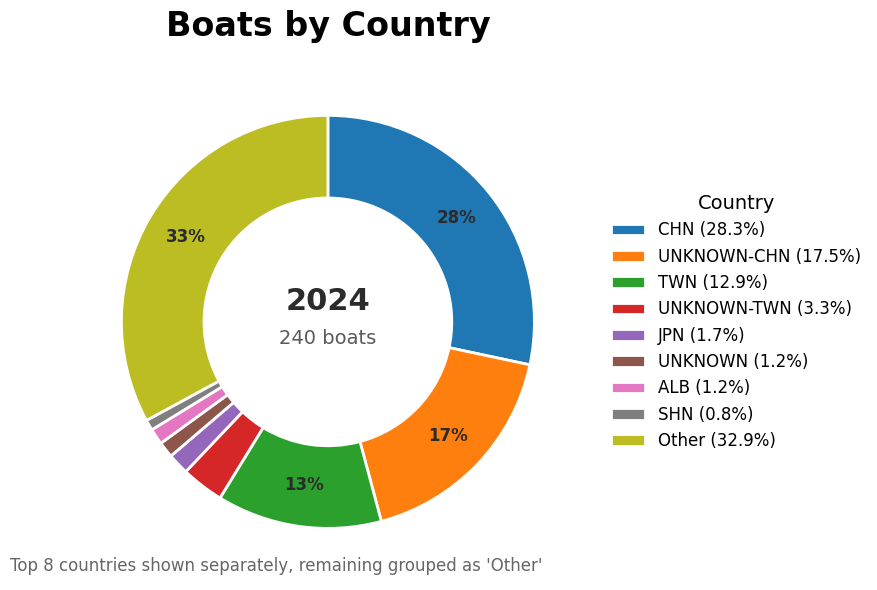

In [25]:
# =========================================
# Parameters
# =========================================
country_col = "flag"      # change if needed
vessel_id_col = "mmsi_present"
top_n = 8
year_label = "2024"       # change if needed

# =========================================
# Compute number of unique boats by country
# =========================================
boats_by_country = (
    df_taiwan.groupby(country_col)[vessel_id_col]
    .nunique()
    .sort_values(ascending=False)
)

total_boats = boats_by_country.sum()

# Keep top N, group the rest as "Other"
top = boats_by_country.iloc[:top_n].copy()
other = boats_by_country.iloc[top_n:].sum()

if other > 0:
    top["Other"] = other

percentages = 100 * top / total_boats

# Labels for legend
legend_labels = [
    f"{country} ({pct:.1f}%)"
    for country, pct in zip(top.index, percentages)
]

# Show percentages only for large enough slices
def autopct_func(pct):
    return f"{pct:.0f}%" if pct >= 4 else ""

# =========================================
# Plot
# =========================================
fig, ax = plt.subplots(figsize=(10, 6))

wedges, _, _ = ax.pie(
    top.values,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.40, edgecolor="white", linewidth=2),
    autopct=autopct_func,
    pctdistance=0.80,
    textprops=dict(color="#2b2b2b", fontsize=12, weight="bold")
)

# Center text
ax.text(0, 0.10, year_label, ha="center", va="center",
        fontsize=22, fontweight="bold", color="#2b2b2b")
ax.text(0, -0.08, f"{total_boats:,} boats", ha="center", va="center",
        fontsize=14, color="#5a5a5a")

# Title
ax.set_title("Boats by Country", fontsize=24, fontweight="bold", pad=20)

# Legend
ax.legend(
    wedges,
    legend_labels,
    title="Country",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=12,
    title_fontsize=14
)

# Footnote
fig.text(
    0.12, 0.04,
    f"Top {top_n} countries shown separately, remaining grouped as 'Other'",
    fontsize=12, color="#666666"
)

plt.tight_layout()
plt.show()

In [26]:
# =========================================
# 1) Filter Chinese vessels
# =========================================
df_china = df_taiwan[df_taiwan["flag"] == "CHN"].copy()

# =========================================
# 2) Unique boats per EEZ
# =========================================
boats_by_eez = (
    df_china.groupby("eez_iso")["mmsi_present"]
    .nunique()
)

total_boats = df_china["mmsi_present"].nunique()

# =========================================
# 3) Split: China EEZ vs Other EEZs
# =========================================
china_eez = boats_by_eez.get("CHN", 0)
foreign_eez = total_boats - china_eez

pct_china = 100 * china_eez / total_boats
pct_foreign = 100 * foreign_eez / total_boats

print(f"Chinese boats in Chinese EEZ: {pct_china:.1f}%")
print(f"Chinese boats in foreign EEZ: {pct_foreign:.1f}%")

Chinese boats in Chinese EEZ: 94.1%
Chinese boats in foreign EEZ: 5.9%


In [27]:
main_eez_per_boat = (
    df_china.groupby(["mmsi_present", "eez_iso"])
    .size()
    .reset_index(name="count")
    .sort_values(["mmsi_present", "count"], ascending=[True, False])
    .drop_duplicates("mmsi_present")
)

boats_by_eez = main_eez_per_boat["eez_iso"].value_counts()
pct_by_eez = boats_by_eez / boats_by_eez.sum() * 100

display(pct_by_eez.head(10))

eez_iso
CHN    94.117647
INT     5.882353
Name: count, dtype: float64

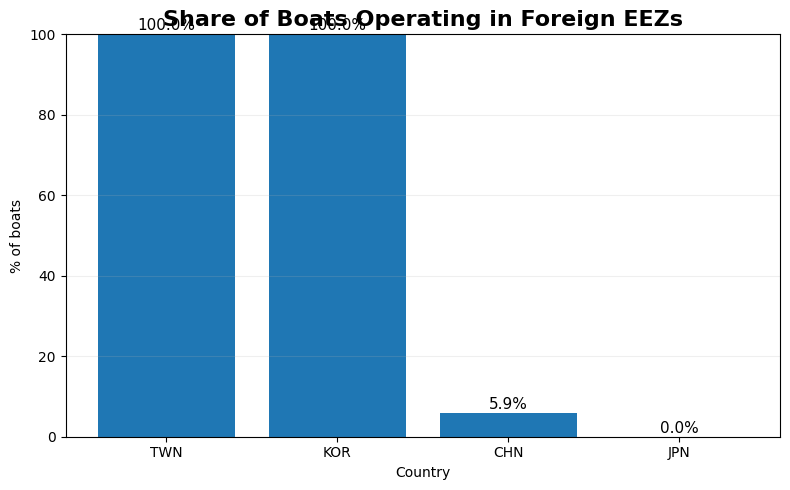

In [28]:
countries = ["CHN", "TWN", "KOR", "JPN"]

results = []

for country in countries:
    df_c = df_taiwan[df_taiwan["flag"] == country]

    total_boats = df_c["mmsi_present"].nunique()

    # Boats per EEZ
    boats_by_eez = (
        df_c.groupby("eez_iso")["mmsi_present"]
        .nunique()
    )

    domestic = boats_by_eez.get(country, 0)
    foreign = total_boats - domestic

    pct_foreign = 100 * foreign / total_boats if total_boats > 0 else 0

    results.append({
        "country": country,
        "pct_foreign": pct_foreign
    })

df_plot = pd.DataFrame(results).sort_values("pct_foreign", ascending=False)

# =========================================
# Plot
# =========================================
plt.figure(figsize=(8, 5))

bars = plt.bar(df_plot["country"], df_plot["pct_foreign"])

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.1f}%", ha="center", fontsize=11)

plt.title("Share of Boats Operating in Foreign EEZs", fontsize=16, weight="bold")
plt.ylabel("% of boats")
plt.xlabel("Country")

plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()